In [72]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sc.settings.figdir = "./plots"
sc.set_figure_params(dpi=100, dpi_save=100)

In [15]:
adata_loop0 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop0/adata_500k.h5ad")
adata_loop1 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop1/adata_500k.h5ad")

## Plot number of MgkPro per recipe

In [67]:
experiments_loop0_vs_mgkpro_prop = {
    "Experiment number": [], 
    "MgK proportion": []
}

for experiment_number in adata_loop0.obs.experiment_number.unique():
    mgk_prop_df = adata_loop0[adata_loop0.obs.experiment_number == experiment_number]
    cell_type_prop = mgk_prop_df.obs.cell_type.value_counts() / mgk_prop_df.shape[0]

    if "late_MgkPro" in cell_type_prop.index:
        mgk_pro_prop = cell_type_prop.loc["late_MgkPro"]
    else: 
        mgk_pro_prop = 0.0
    
    experiments_loop0_vs_mgkpro_prop["Experiment number"].append(experiment_number)
    experiments_loop0_vs_mgkpro_prop["MgK proportion"].append(mgk_pro_prop)

In [73]:
experiments_loop0_vs_mgkpro_prop = pd.DataFrame(experiments_loop0_vs_mgkpro_prop)

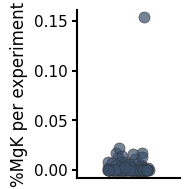

In [113]:
fig, ax = plt.subplots(figsize=(2, 2))
sns.stripplot(
    data=experiments_loop0_vs_mgkpro_prop,
    y="MgK proportion",
    jitter=0.2,
    alpha=0.7,
    size=8,
    color="#3a4f6a",
    linewidth=0.5,
    ax=ax
)
ax.set_xlabel("")
ax.set_ylabel("%MgK per experiment", fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.2f}"))
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_linewidth(1.5)
ax.tick_params(bottom=False, width=1.5, labelsize=11)
plt.tight_layout()
plt.savefig("mgkpro_stripplot.svg", format="svg", bbox_inches="tight")
plt.show()

In [124]:
for exp in np.unique(adata_loop0.obs.experiment_number):
    print(exp)

40
41
42
43
53
54
55
65
66
67
77
78
79
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
125
126
127
128
129
130
131
133
138
139
140
141
142
143
144
145
146
147
157
158
159
160
161
162
163
164
188
189
205
1089
1090
1091
1092
1093
1094
1095
1096
1097
1098
1099
1100
1101
1102
1103
1104
1111
1112
1113
1114
1115
1116
1117
1118
1119
1120
1138
1139
1140
1141
1142
1143
1144
1145
1146
1147
1169
1170
1171
1172
1173
1174
1175
1176
1177
1178
1179
1180
1181
1182
1188
1189
2138
2139
4138
4139


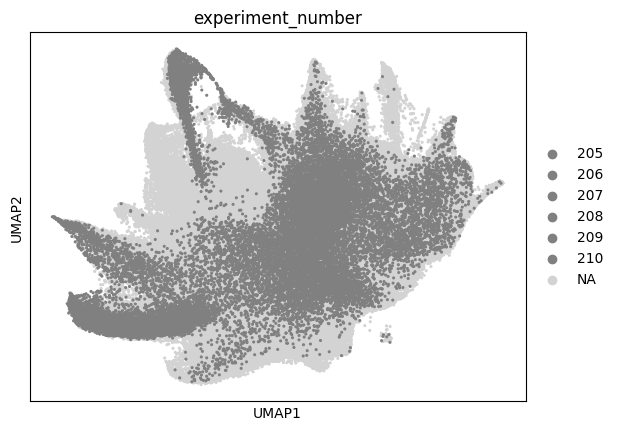

In [140]:
adata_loop1.obs["experiment_number"] = adata_loop1.obs["experiment_number"].astype("category")
sc.pl.umap(
    adata_loop1,
    s=20, 
    color="experiment_number", 
    groups=[205, 206, 207, 208, 209, 210]
)

In [134]:
np.unique(adata_loop1.obs["experiment_number"])

array([  40,   41,   42,   43,   53,   54,   55,   65,   66,   67,   77,
         78,   79,  105,  106,  107,  108,  109,  110,  111,  112,  113,
        114,  115,  116,  117,  118,  119,  120,  121,  122,  123,  125,
        126,  127,  128,  129,  130,  131,  133,  138,  139,  140,  141,
        142,  143,  144,  145,  146,  147,  157,  158,  159,  160,  161,
        162,  163,  164,  188,  189,  205,  206,  207,  208,  209,  210,
       1089, 1090, 1091, 1092, 1093, 1094, 1095, 1096, 1097, 1098, 1099,
       1100, 1101, 1102, 1103, 1104, 1111, 1112, 1113, 1114, 1115, 1116,
       1117, 1118, 1119, 1120, 1138, 1139, 1140, 1141, 1142, 1143, 1144,
       1145, 1146, 1147, 1169, 1170, 1171, 1172, 1173, 1174, 1175, 1176,
       1177, 1178, 1179, 1180, 1181, 1182, 1188, 1189, 2138, 2139, 4138,
       4139])